# Motion Correction — diagnosis and tuning

This notebook covers **rigid motion correction only** (no neuron extraction).

Supported data sources:
| `SOURCE` | Data | Ground-truth drift? |
|----------|------|---------------------|
| `"zarr"` | Real recording from disk (zarr store) | ✗ |
| `"realistic_sim"` | Realistic 1p miniscope simulator (shot noise, background, ghost cells) | ✓ |
| `"simple_sim"` | Clean synthetic movie (6 neurons, no artefacts) | ✓ |

**Start with §1 (diagnosis) if motion correction returns near-zero shifts on your real video.**

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# ── Data source ───────────────────────────────────────────────────────────────
SOURCE    = "zarr"                       # "zarr" | "realistic_sim" | "simple_sim"
ZARR_PATH = "../real_vids/movie.zarr"   # only used when SOURCE="zarr"

# Simulation parameters (ignored when SOURCE="zarr")
SIM_MOTION_MAX_SHIFT = 4.0
SIM_SEED             = 7

# Add tests/ so we can import the simulators directly
tests_dir = str(Path("../tests").resolve())
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

In [2]:
has_ground_truth = False
true_shifts      = None

if SOURCE == "realistic_sim":
    from miniscope_simulator import make_miniscope_movie
    print("Generating realistic miniscope movie (64×64, T=100) …")
    t0  = time.time()
    sim = make_miniscope_movie(
        n_neurons=5, dims=(64, 64), T=100,
        motion_max_shift=SIM_MOTION_MAX_SHIFT, seed=SIM_SEED, quantize_8bit=False,
    )
    movie_arr    = sim["movie"].astype(np.float32)
    true_shifts  = sim["motion_shifts"]
    has_ground_truth = True
    print(f"Done in {time.time()-t0:.1f} s")

elif SOURCE == "simple_sim":
    from conftest import make_synthetic_movie
    print("Generating simple synthetic movie (64×64, T=300) …")
    t0     = time.time()
    result = make_synthetic_movie(H=64, W=64, T=300, K=6, sigma=3,
                                   motion_max_shift=SIM_MOTION_MAX_SHIFT, seed=SIM_SEED)
    movie_arr        = result["movie"].astype(np.float32)
    true_shifts      = result.get("motion_shifts", None)
    has_ground_truth = true_shifts is not None
    print(f"Done in {time.time()-t0:.1f} s")

elif SOURCE == "zarr":
    from minicnmfe.io import open_zarr
    zarr_path = Path(ZARR_PATH)
    if not zarr_path.exists():
        raise FileNotFoundError(f"{zarr_path} not found.")
    z         = open_zarr(zarr_path)
    print(f"Opened zarr: {z.shape}  chunks={z.chunks}  dtype={z.dtype}")
    # Load a manageable sub-clip for diagnosis; use z directly for the full run
    N_DIAG    = min(500, z.shape[0])
    print(f"Loading first {N_DIAG} frames for analysis …")
    movie_arr = np.asarray(z[:N_DIAG], dtype=np.float32)
    print(f"Loaded: {movie_arr.shape}")
else:
    raise ValueError(f"Unknown SOURCE={SOURCE!r}")

T, H, W = movie_arr.shape
print(f"\nMovie: {T} × {H} × {W}   ground truth: {has_ground_truth}")

Opened zarr: (1000, 518, 510)  chunks=(100, 518, 510)  dtype=uint8
Loading first 500 frames for analysis …
Loaded: (500, 518, 510)

Movie: 500 × 518 × 510   ground truth: False


## Preview — sample frames

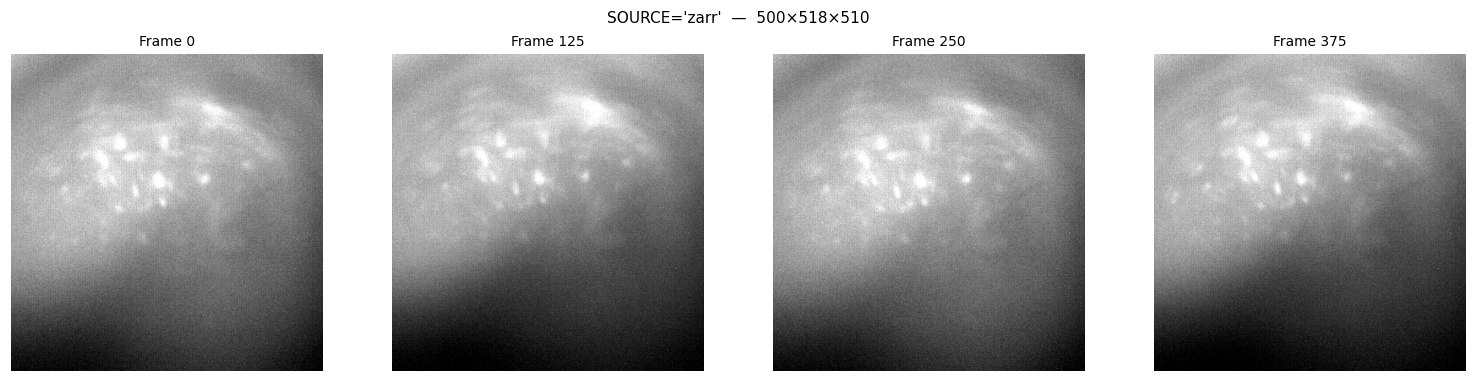

In [3]:
frame_indices = [0, T // 4, T // 2, 3 * T // 4]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, t in zip(axes, frame_indices):
    frame = movie_arr[t]
    vmax  = float(np.percentile(frame, 99.5))
    ax.imshow(frame, cmap="gray", vmin=0, vmax=vmax)
    ax.set_title(f"Frame {t}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"SOURCE={SOURCE!r}  —  {T}×{H}×{W}", fontsize=10)
plt.tight_layout()
plt.show()

---
## §1. Diagnosis: why does phase correlation return near-zero shifts on real 1p movies?

### Root cause A — the vignette / background

Every miniscope recording has:
- A **slow, spatially broad fluorescence background** (hundreds of px wide)
- A **circular vignette** (the GRIN lens boundary — dark outside, bright inside)

These two features are **fixed to the optics** — they do not move when the brain drifts.
They dominate the low-frequency content of every frame.

Phase correlation computes a normalized cross-power spectrum and finds its peak.
When the background is fixed and bright, its autocorrelation creates a huge spike at
`(dy, dx) = (0, 0)`. The true-shift peak from the neurons sits on top of this — much
smaller — and is missed.

### Root cause B — `gSig_filt` must match the neuron size

The fix is `gSig_filt`: a centered Gaussian high-pass kernel (same trick CaImAn uses)
applied to both frame and template *before* computing the phase correlation. It removes
all spatial structure larger than `~3 × gSig_filt` pixels.

| `gSig_filt` | Kernel size | Suppresses structure > |
|-------------|-------------|------------------------|
| 1 | 3 × 3 | ~3 px ← **too small; does nothing against vignette** |
| 3 | 7 × 7 | ~9 px |
| 5 | 13 × 13 | ~15 px |
| 8 | 19 × 19 | ~24 px |

**Rule of thumb:** set `gSig_filt ≈ neuron_sigma` where `neuron_sigma ≈ neuron_diameter / 4`.
For a typical miniscope at standard zoom, neurons are 10–30 px in diameter → `gSig_filt = 3–8`.

The cell below shows you the cross-correlation surface so you can see the problem and
tune `gSig_filt` interactively.

Detected 6 blobs — median diameter ≈ 3.3 px
Suggested gSig_filt ≈ 2  (= diameter / 4)


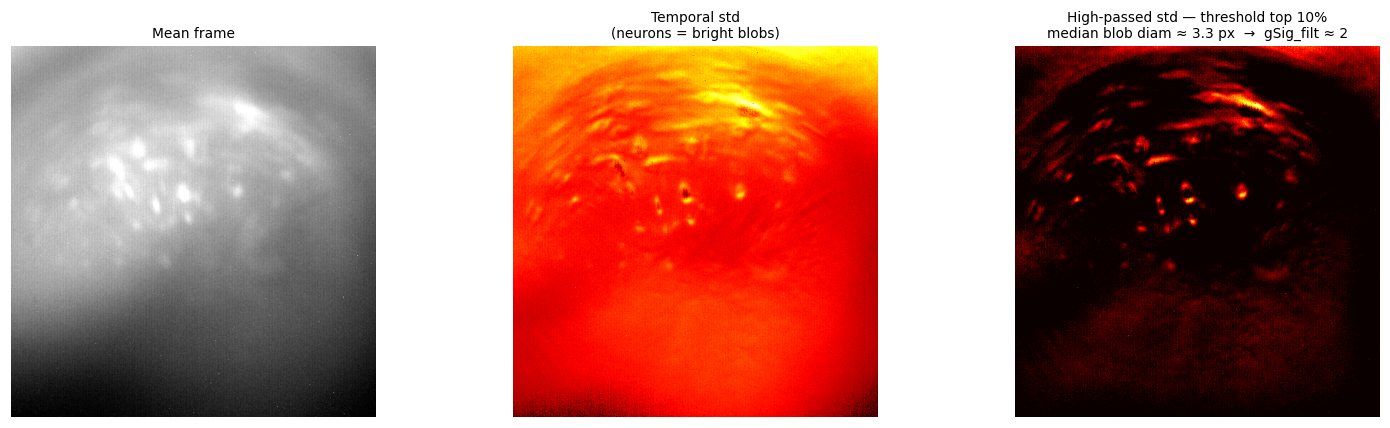

In [4]:
# ── Estimate neuron size from temporal std image ──────────────────────────────
# The temporal std is bright where calcium fluorescence fluctuates → neuron locations.
# Estimate the typical bright-blob diameter to choose gSig_filt.
from scipy.ndimage import gaussian_filter, label

stride   = max(1, T // 200)
std_img  = movie_arr[::stride].std(axis=0)
mean_img = movie_arr[::stride].mean(axis=0)

# High-pass the std image to isolate neuron-scale blobs
std_hp   = np.clip(std_img - gaussian_filter(std_img, sigma=max(H, W) / 10), 0, None)
thr      = np.percentile(std_hp, 90)
blobs    = std_hp > thr
labeled, n_blobs = label(blobs)

# Estimate median blob diameter (approx)
blob_sizes = []
for b in range(1, min(n_blobs + 1, 50)):
    coords = np.argwhere(labeled == b)
    if len(coords) < 5:
        continue
    diam = 2.0 * np.sqrt(len(coords) / np.pi)
    blob_sizes.append(diam)

if blob_sizes:
    median_diam  = float(np.median(blob_sizes))
    suggested_gSig = max(2, round(median_diam / 4))
    print(f"Detected {len(blob_sizes)} blobs — median diameter ≈ {median_diam:.1f} px")
    print(f"Suggested gSig_filt ≈ {suggested_gSig}  (= diameter / 4)")
else:
    suggested_gSig = 5
    print("Could not auto-detect blobs — defaulting to gSig_filt=5")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(mean_img, cmap="gray", vmin=0, vmax=float(np.percentile(mean_img, 99.5)))
axes[0].set_title("Mean frame", fontsize=9)
axes[0].axis("off")
axes[1].imshow(std_img, cmap="hot")
axes[1].set_title("Temporal std\n(neurons = bright blobs)", fontsize=9)
axes[1].axis("off")
axes[2].imshow(std_hp, cmap="hot")
axes[2].set_title(f"High-passed std — threshold top 10%\n"
                  f"median blob diam ≈ {median_diam if blob_sizes else '?':.1f} px  →  gSig_filt ≈ {suggested_gSig}",
                  fontsize=9)
axes[2].axis("off")
plt.tight_layout()
plt.show()

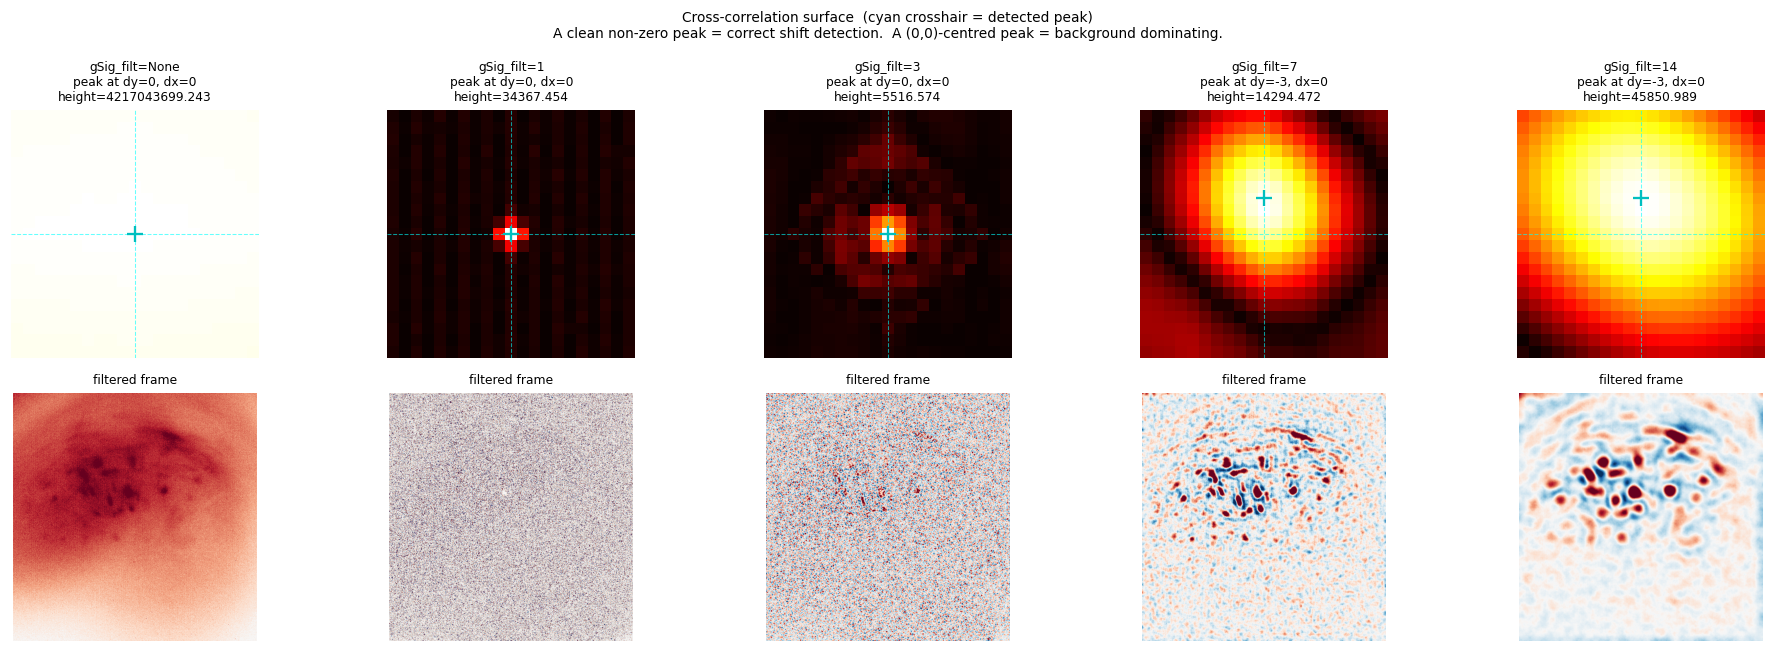


Summary:
     gSig_filt   peak_dy   peak_dx    height
          None         0         0  4217043699.2434
             1         0         0  34367.4538
             3         0         0  5516.5740
             7        -3         0  14294.4724
            14        -3         0  45850.9890


In [5]:
# ── Cross-correlation surface for different gSig_filt values ─────────────────
# Pick a frame with visible motion (use the middle of the clip).
from minicnmfe.motion_correction_claude import cross_correlation_surface
suggested_gSig = 7
MAX_SHIFT      = (10, 10)
template_frame = movie_arr[:min(50, T)].mean(axis=0)   # template from first 50 frames
probe_frame    = movie_arr[T // 2]                      # probe from the middle

gSig_values = [None, 1, 3, suggested_gSig, suggested_gSig * 2]
gSig_values = list(dict.fromkeys(gSig_values))          # deduplicate, preserve order

n_panels = len(gSig_values)
fig, axes = plt.subplots(2, n_panels, figsize=(3.5 * n_panels, 6))

peak_vals   = []
peak_shifts = []

for col, gSig in enumerate(gSig_values):
    surf, filt_frame, filt_templ = cross_correlation_surface(
        probe_frame, template_frame, max_shift=MAX_SHIFT, gSig_filt=gSig,
    )
    flat_idx = int(np.argmax(surf))
    msy, msx = MAX_SHIFT
    py, px   = np.unravel_index(flat_idx, surf.shape)
    dy, dx   = py - msy, px - msx
    peak_val = float(surf.flat[flat_idx])
    peak_vals.append(peak_val)
    peak_shifts.append((dy, dx))

    lbl = f"gSig_filt={gSig}" if gSig else "gSig_filt=None"
    vmax_s = float(np.abs(surf).max())
    axes[0, col].imshow(surf, cmap="hot", vmin=0, vmax=vmax_s)
    axes[0, col].axhline(msy, color="cyan", lw=0.7, ls="--", alpha=0.6)
    axes[0, col].axvline(msx, color="cyan", lw=0.7, ls="--", alpha=0.6)
    axes[0, col].plot(px, py, "c+", ms=10, mew=1.5)
    axes[0, col].set_title(f"{lbl}\npeak at dy={dy}, dx={dx}\nheight={peak_val:.3f}", fontsize=8)
    axes[0, col].axis("off")

    # Show the filtered frame
    fv = float(np.percentile(np.abs(filt_frame), 99))
    axes[1, col].imshow(filt_frame, cmap="RdBu_r", vmin=-fv, vmax=fv)
    axes[1, col].set_title(f"filtered frame", fontsize=8)
    axes[1, col].axis("off")

plt.suptitle("Cross-correlation surface  (cyan crosshair = detected peak)\n"
             "A clean non-zero peak = correct shift detection.  "
             "A (0,0)-centred peak = background dominating.", fontsize=9)
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"  {'gSig_filt':>12s}  {'peak_dy':>8s}  {'peak_dx':>8s}  {'height':>8s}")
for gSig, (dy, dx), pv in zip(gSig_values, peak_shifts, peak_vals):
    print(f"  {str(gSig):>12s}  {dy:8d}  {dx:8d}  {pv:8.4f}")

### How to read the surface plots

- **Bright spot in the centre** (dy=0, dx=0) — the vignette / background dominates;
  `gSig_filt` too small or not set.
- **Bright spot at a non-zero location** — phase correlation found the shift; that
  `gSig_filt` value is good.
- **Flat, noisy surface** — even after filtering, SNR is too low; try a larger `max_shift`
  or use ROI (see §2).

Choose the smallest `gSig_filt` that moves the peak away from centre and set it in the
motion-correction cell below.

---
## §2. ROI — restrict shift estimation to the neuron-dense core

The circular FOV boundary (sharp ring where the lens goes dark) is **fixed to the optics**.
Even after high-pass filtering, the ring edge is a strong high-frequency feature in every
frame and always creates a `(0,0)` contribution in the cross-correlation.

`select_roi()` finds the sub-rectangle with the highest concentration of flickering pixels
(= neurons). Restricting shift estimation to that rectangle:
1. Excludes the dark boundary ring → removes the dominant static artefact
2. Focuses phase correlation on the region where neurons provide the most signal

The shift is still **applied to the full frame** — only estimation uses the crop.

Selected ROI: y=51:310  x=138:393
ROI size: 259 × 255 px


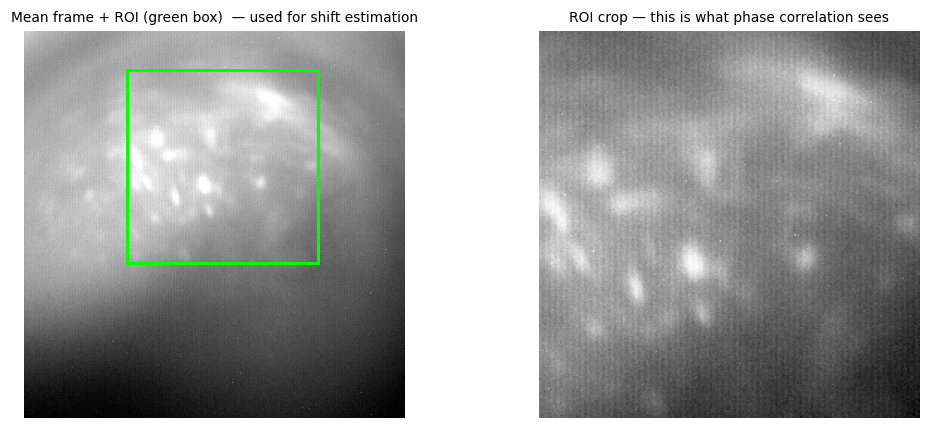

In [6]:
from minicnmfe.motion_correction_claude import select_roi

# hp_sigma should be large enough to remove the vignette gradient (use 10–25% of FOV size)
HP_SIGMA     = max(H, W) * 0.10
BORDER_MARGIN = max(5, min(H, W) // 10)

roi = select_roi(
    movie_arr, frac_h=0.5, frac_w=0.5,
    n_frames=min(200, T),
    border_margin=BORDER_MARGIN,
    hp_sigma=HP_SIGMA,
)
print(f"Selected ROI: y={roi[0].start}:{roi[0].stop}  x={roi[1].start}:{roi[1].stop}")
print(f"ROI size: {roi[0].stop-roi[0].start} × {roi[1].stop-roi[1].start} px")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(mean_img, cmap="gray", vmin=0, vmax=float(np.percentile(mean_img, 99.5)))
axes[0].add_patch(plt.Rectangle(
    (roi[1].start, roi[0].start),
    roi[1].stop - roi[1].start, roi[0].stop - roi[0].start,
    edgecolor="lime", facecolor="none", lw=2,
))
axes[0].set_title("Mean frame + ROI (green box)  — used for shift estimation", fontsize=9)
axes[0].axis("off")
axes[1].imshow(mean_img[roi], cmap="gray")
axes[1].set_title("ROI crop — this is what phase correlation sees", fontsize=9)
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Override roi manually if the auto-selection looks wrong, e.g.:
# roi = (slice(100, 400), slice(150, 450))

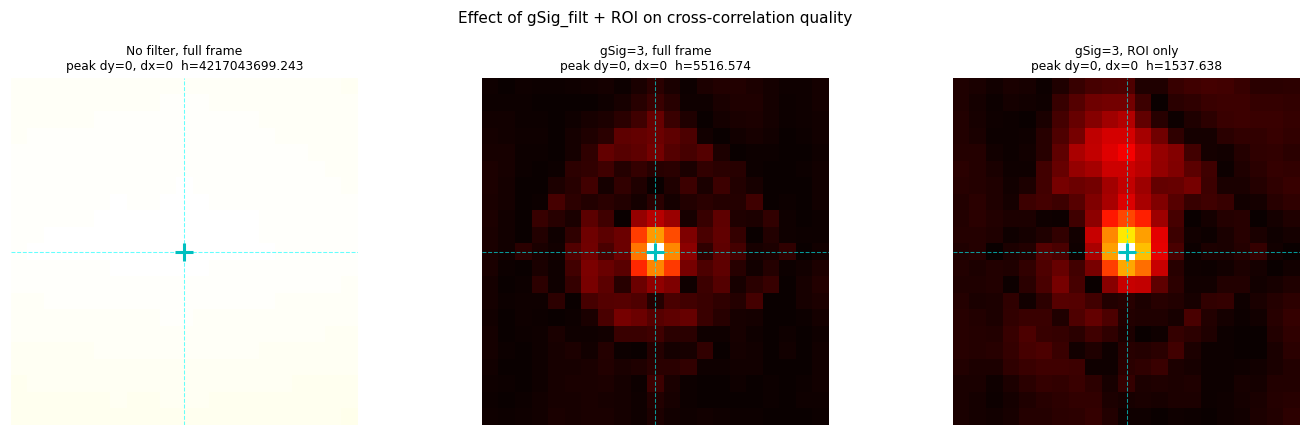

In [7]:
# ── CC surface WITH ROI + gSig_filt — should now show a clean non-zero peak ──
template_roi = template_frame[roi]
probe_roi    = probe_frame[roi]
suggested_gSig = 3
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
configs = [
    ("No filter, full frame", probe_frame,    template_frame,  None),
    (f"gSig={suggested_gSig}, full frame",   probe_frame,    template_frame,  suggested_gSig),
    (f"gSig={suggested_gSig}, ROI only",     probe_roi,      template_roi,    suggested_gSig),
]
for ax, (title, frm, tpl, gs) in zip(axes, configs):
    surf, _, _ = cross_correlation_surface(frm, tpl, max_shift=MAX_SHIFT, gSig_filt=gs)
    flat_idx   = int(np.argmax(surf))
    msy, msx   = MAX_SHIFT
    py, px     = np.unravel_index(flat_idx, surf.shape)
    dy, dx     = py - msy, px - msx
    peak_val   = float(surf.flat[flat_idx])
    ax.imshow(surf, cmap="hot", vmin=0, vmax=float(np.abs(surf).max()))
    ax.axhline(msy, color="cyan", lw=0.7, ls="--", alpha=0.6)
    ax.axvline(msx, color="cyan", lw=0.7, ls="--", alpha=0.6)
    ax.plot(px, py, "c+", ms=12, mew=2)
    ax.set_title(f"{title}\npeak dy={dy}, dx={dx}  h={peak_val:.3f}", fontsize=8)
    ax.axis("off")
plt.suptitle("Effect of gSig_filt + ROI on cross-correlation quality", fontsize=10)
plt.tight_layout()
plt.show()

### Root cause C — border artifacts from the high-pass filter

`_high_pass_filter_space` subtracts a Gaussian-blurred copy of the frame.
With `mode="constant"` (zero-padding), every edge pixel sees a sharp 0-to-bright
transition — the same in every frame *and* the template → a systematic (0,0) CC
contribution.  **This is now fixed** (`mode="reflect"` is used by default).

### Root cause D — what to do when gSig_filt cannot suppress the vignette

For a 600×600 FOV the GRIN lens vignette spans ~500 px.  A Gaussian high-pass with
`gSig_filt=40` removes only ~8% of a 500 px structure; you would need `gSig_filt≈300`
(≈ the FOV radius) to suppress it by 99%.  Values that large also destroy the neuron
signal.

**Solution: `percentile_threshold`**

After optional `gSig_filt`, both frame and template are soft-thresholded:

```
thr = percentile(template, N)       # computed on noise-free template
frame    = clip(frame    - thr, 0)
template = clip(template - thr, 0)
```

Setting `percentile_threshold=90` zeroes out the faint 90% (background / vignette /
neuropil) and keeps only the top 10% — the bright neuron-like pixels.
Phase correlation then sees only neuron structure → no background at (0,0) regardless
of its spatial scale.

The cell below compares CC surfaces with and without this threshold.

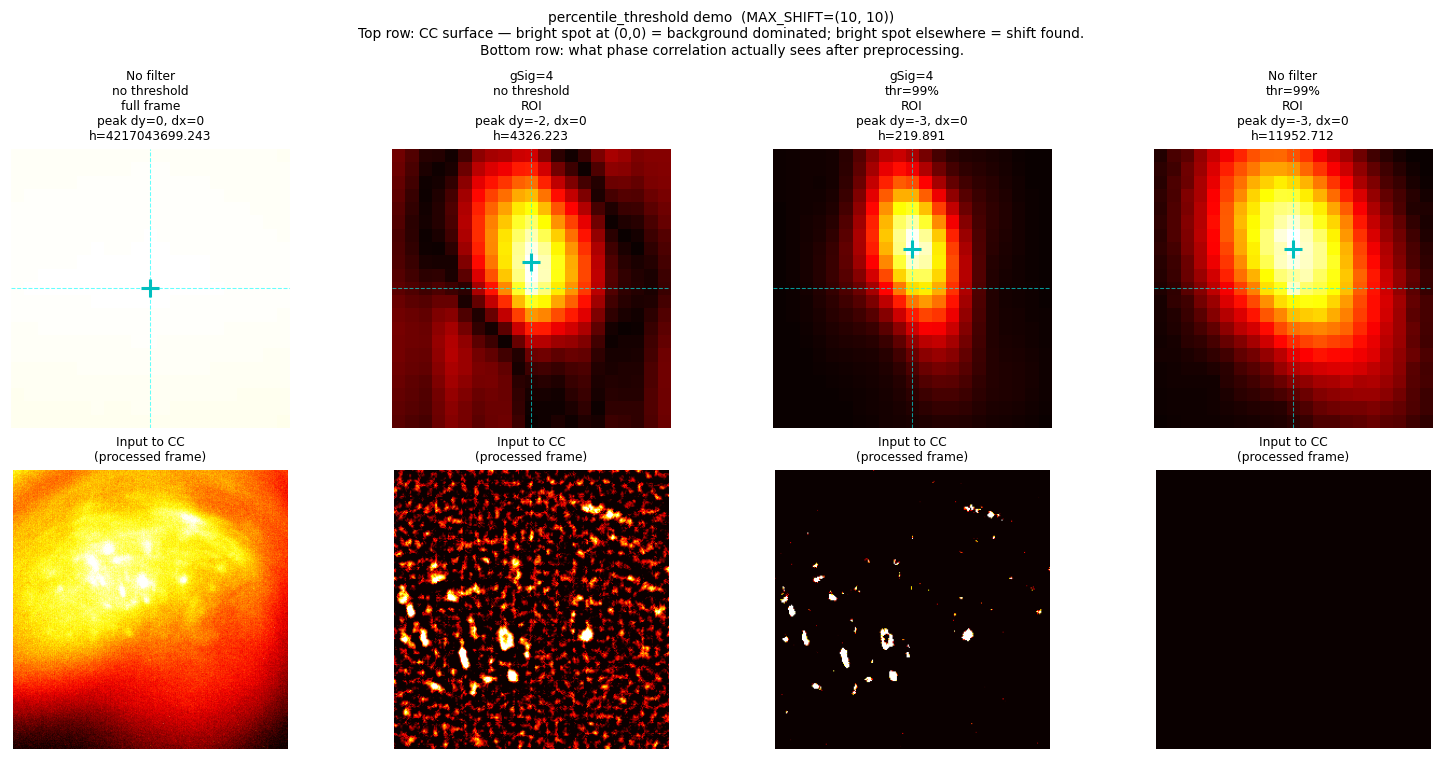


Suggested parameters for your data:
  gSig_filt           = 4
  percentile_threshold = 99  (adjust: lower if peak disappears, raise to suppress more bg)
  roi                 = True (§2 selection)
  temporal_smooth_sigma = 7.0


In [8]:
# ── percentile_threshold: keep only the brightest (neuron-like) pixels ────────
#
# Vary percentile_threshold and see how the CC surface changes.
# With threshold=90:  only top 10% of pixels (neurons) contribute to the CC.
# With threshold=None: all pixels contribute — background/vignette dominates.

PERCENTILE_THR = 99   # ← starting point; lower if you lose the peak, raise to reduce noise
suggested_gSig = 4
template_roi = template_frame[roi]
probe_roi    = probe_frame[roi]

configs_pct = [
    ("No filter\nno threshold\nfull frame",   probe_frame, template_frame, None,            None),
    (f"gSig={suggested_gSig}\nno threshold\nROI",   probe_roi,   template_roi,   suggested_gSig, None),
    (f"gSig={suggested_gSig}\nthr={PERCENTILE_THR}%\nROI",
                                               probe_roi,   template_roi,   suggested_gSig, PERCENTILE_THR),
    (f"No filter\nthr={PERCENTILE_THR}%\nROI", probe_roi,   template_roi,   None,            PERCENTILE_THR),
]

fig, axes = plt.subplots(2, len(configs_pct), figsize=(3.5 * len(configs_pct), 7))

for col, (title, frm, tpl, gs, pct) in enumerate(configs_pct):
    surf, filt_f, filt_t = cross_correlation_surface(
        frm, tpl, max_shift=MAX_SHIFT, gSig_filt=gs, percentile_threshold=pct,
    )
    flat_idx = int(np.argmax(surf))
    msy, msx = MAX_SHIFT
    py, px   = np.unravel_index(flat_idx, surf.shape)
    dy, dx   = py - msy, px - msx
    peak_val = float(surf.flat[flat_idx])

    axes[0, col].imshow(surf, cmap="hot", vmin=0, vmax=float(np.abs(surf).max()))
    axes[0, col].axhline(msy, color="cyan", lw=0.7, ls="--", alpha=0.6)
    axes[0, col].axvline(msx, color="cyan", lw=0.7, ls="--", alpha=0.6)
    axes[0, col].plot(px, py, "c+", ms=12, mew=2)
    axes[0, col].set_title(f"{title}\npeak dy={dy}, dx={dx}\nh={peak_val:.3f}", fontsize=8)
    axes[0, col].axis("off")

    # show thresholded frame (what CC actually sees)
    fv = float(np.percentile(np.abs(filt_f), 99)) if np.abs(filt_f).max() > 0 else 1.0
    axes[1, col].imshow(filt_f, cmap="hot", vmin=0, vmax=fv)
    axes[1, col].set_title("Input to CC\n(processed frame)", fontsize=8)
    axes[1, col].axis("off")

plt.suptitle(
    f"percentile_threshold demo  (MAX_SHIFT={MAX_SHIFT})\n"
    "Top row: CC surface — bright spot at (0,0) = background dominated; "
    "bright spot elsewhere = shift found.\n"
    "Bottom row: what phase correlation actually sees after preprocessing.",
    fontsize=9,
)
plt.tight_layout()
plt.show()

print(f"\nSuggested parameters for your data:")
print(f"  gSig_filt           = {suggested_gSig}")
print(f"  percentile_threshold = {PERCENTILE_THR}  (adjust: lower if peak disappears, raise to suppress more bg)")
print(f"  roi                 = True (§2 selection)")
print(f"  temporal_smooth_sigma = 7.0")

---
## §3. Motion correction with correct parameters

Set `GSIG_FILT` based on what you saw in §1: the value that moves the CC surface peak
away from (0,0).

In [14]:
from minicnmfe.motion_correction_claude import motion_correct
suggested_gSig = 7
USE_ROI = False
# ── Key parameters — tune based on §1 and §2 ─────────────────────────────────
GSIG_FILT      = suggested_gSig   # ← set this based on §1 CC surface diagnosis
PERCENTILE_THR = 10               # ← keep top (100-N)% pixels; None to disable
# USE_ROI        = True             # ← recommended for real videos with circular FOV
MAX_SHIFT_MC   = (20, 20)         # ← increase if drift is larger than 20 px
N_ITER         = 1
SMOOTH_SIGMA   = 0              # ← temporal smoothing (frames); 0 to disable

mc_roi = roi if USE_ROI else None

print(f"Running MC: gSig_filt={GSIG_FILT}  pct_thr={PERCENTILE_THR}  roi={USE_ROI}  "
      f"max_shift={MAX_SHIFT_MC}  smooth={SMOOTH_SIGMA}")
t0 = time.time()
mc_arr, shifts = motion_correct(
    movie_arr,
    n_iter=N_ITER,
    max_shift=MAX_SHIFT_MC,
    upsample_factor=10,
    gSig_filt=GSIG_FILT,
    percentile_threshold=PERCENTILE_THR,
    roi=mc_roi,
    temporal_smooth_sigma=SMOOTH_SIGMA,
)
print(f"Done in {time.time()-t0:.1f} s")
print(f"Shift range:  dy=[{shifts[:,0].min():.2f}, {shifts[:,0].max():.2f}]  "
      f"dx=[{shifts[:,1].min():.2f}, {shifts[:,1].max():.2f}] px")

if has_ground_truth and true_shifts is not None:
    for ax, lbl in enumerate(["dy", "dx"]):
        r = abs(float(np.corrcoef(shifts[:, ax], true_shifts[:, ax])[0, 1]))
        print(f"  |r| vs true drift  {lbl} = {r:.3f}")

Running MC: gSig_filt=7  pct_thr=10  roi=False  max_shift=(20, 20)  smooth=0


Motion correction pass 1/1: 100%|██████████| 5/5 [02:14<00:00, 26.89s/it]

Done in 194.4 s
Shift range:  dy=[-2.50, 5.30]  dx=[-0.50, 1.10] px


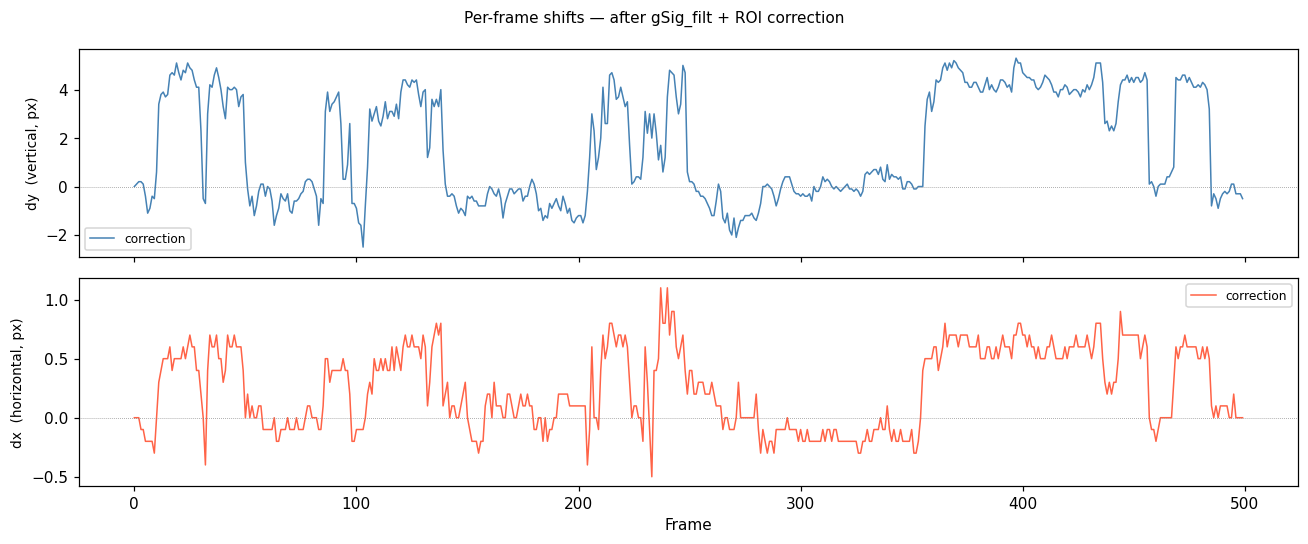

In [16]:
# ── Shift trajectory ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, dim, lbl, col in zip(axes, [0, 1],
                              ["dy  (vertical, px)", "dx  (horizontal, px)"],
                              ["steelblue", "tomato"]):
    if true_shifts is not None:
        ax.plot(true_shifts[:, dim], lw=1.5, ls="--", color="k", alpha=0.7, label="true drift")
        ax.plot(-shifts[:, dim], lw=1.0, color=col, label="−correction")
    else:
        ax.plot(shifts[:, dim], lw=1.0, color=col, label="correction")
    ax.set_ylabel(lbl, fontsize=9)
    ax.legend(fontsize=8)
    ax.axhline(0, color="gray", lw=0.5, ls=":")
axes[-1].set_xlabel("Frame")
plt.suptitle("Per-frame shifts — after gSig_filt + ROI correction", fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
# ── Save motion-corrected movie ───────────────────────────────────────────────
# Set SAVE_FORMAT to "zarr", "mp4", or None to skip.
SAVE_FORMAT = "zarr"
SAVE_PATH   = "../real_vids/movie_mc.zarr"   # change extension to .mp4 for video

FPS         = 30

if SAVE_FORMAT == "zarr":
    from minicnmfe.io import save_zarr
    mc_np = np.asarray(mc_arr, dtype=np.float32)
    save_zarr(mc_np, SAVE_PATH)
    print(f"Saved zarr → {SAVE_PATH}  shape={mc_np.shape}")

elif SAVE_FORMAT == "mp4":
    import shutil, subprocess
    mc_np     = np.asarray(mc_arr)
    lo, hi    = float(mc_np.min()), float(mc_np.max())
    frames_u8 = ((mc_np - lo) / (hi - lo + 1e-6) * 255).clip(0, 255).astype(np.uint8)
    H_v, W_v  = frames_u8.shape[1], frames_u8.shape[2]
    t0 = time.time()

    # Fastest: pipe raw frames to ffmpeg; libx264 ultrafast ~5-20× faster than cv2/mp4v
    saved = False
    if shutil.which("ffmpeg"):
        proc = subprocess.Popen(
            ["ffmpeg", "-y", "-f", "rawvideo", "-vcodec", "rawvideo",
             "-s", f"{W_v}x{H_v}", "-pix_fmt", "gray", "-r", str(FPS),
             "-i", "pipe:", "-vcodec", "libx264", "-preset", "ultrafast",
             "-crf", "23", "-pix_fmt", "yuv420p", SAVE_PATH],
            stdin=subprocess.PIPE, stderr=subprocess.DEVNULL,
        )
        proc.communicate(input=frames_u8.tobytes())
        saved = proc.returncode == 0

    if not saved:   # fallback: cv2 frame-by-frame
        try:
            import cv2
            out = cv2.VideoWriter(SAVE_PATH, cv2.VideoWriter_fourcc(*"mp4v"), FPS, (W_v, H_v), False)
            for f in frames_u8:
                out.write(f)
            out.release()
            saved = True
        except Exception:
            import imageio
            imageio.mimwrite(SAVE_PATH, frames_u8, fps=FPS, codec="libx264")

    print(f"Saved mp4 → {SAVE_PATH}  ({len(frames_u8)} frames, {time.time()-t0:.1f} s)")

elif SAVE_FORMAT is None:
    print("Skipping save (SAVE_FORMAT=None).")

Saved zarr → ../real_vids/movie_mc.zarr  shape=(500, 518, 510)


In [ ]:
# ── Mean frame before vs after ────────────────────────────────────────────────
mean_raw = movie_arr.mean(axis=0)
mean_mc  = np.asarray(mc_arr, dtype=np.float32).mean(axis=0)
vmax_m   = float(np.percentile(mean_mc, 99.5))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(mean_raw, cmap="gray", vmin=0, vmax=vmax_m)
axes[0].set_title("Raw (no correction)", fontsize=9)
axes[0].axis("off")
axes[1].imshow(mean_mc, cmap="gray", vmin=0, vmax=vmax_m)
axes[1].set_title(f"MC  (gSig={GSIG_FILT}, smooth={SMOOTH_SIGMA})", fontsize=9)
axes[1].axis("off")
diff = mean_mc - mean_raw
dmax = float(np.abs(diff).max()) + 1e-6
axes[2].imshow(diff, cmap="RdBu_r", vmin=-dmax, vmax=dmax)
axes[2].set_title("Difference  MC − raw", fontsize=9)
axes[2].axis("off")
plt.suptitle("Temporal mean — better correction → sharper neuron blobs", fontsize=10)
plt.tight_layout()
plt.show()

---
## §4. Temporal smoothing — suppressing per-frame noise

Even with correct `gSig_filt` and ROI, individual frame estimates are noisy because
neuron transients are sparse (only a few cells are active per frame). 

**Brain drift is a slow, smooth process** — a correlated random walk.
Applying a Gaussian temporal low-pass (sigma ≈ 5–10 frames) suppresses the
high-frequency noise in the shift estimates while preserving the true slow drift.

After smoothing the shift trajectory, the smoothed shifts are re-applied to the
*original* movie so the corrected output is self-consistent.

In [ ]:
# Compare: no smoothing vs smoothing (same gSig_filt + ROI + percentile_threshold)
print("Running MC without smoothing …")
t0 = time.time()
_, shifts_raw = motion_correct(
    movie_arr, n_iter=N_ITER, max_shift=MAX_SHIFT_MC, upsample_factor=10,
    gSig_filt=GSIG_FILT, percentile_threshold=PERCENTILE_THR,
    roi=mc_roi, temporal_smooth_sigma=0.0,
)
print(f"  done in {time.time()-t0:.1f} s")

SMOOTH_SIGMA = 7.0
print(f"Running MC with temporal_smooth_sigma={SMOOTH_SIGMA} …")
t0 = time.time()
_, shifts_smooth = motion_correct(
    movie_arr, n_iter=N_ITER, max_shift=MAX_SHIFT_MC, upsample_factor=10,
    gSig_filt=GSIG_FILT, percentile_threshold=PERCENTILE_THR,
    roi=mc_roi, temporal_smooth_sigma=SMOOTH_SIGMA,
)
print(f"  done in {time.time()-t0:.1f} s")

jitter_raw    = float(np.diff(shifts_raw,    axis=0).std())
jitter_smooth = float(np.diff(shifts_smooth, axis=0).std())
print(f"\nFrame-to-frame jitter:")
print(f"  raw     : {jitter_raw:.4f} px")
print(f"  smoothed: {jitter_smooth:.4f} px  ({100*(jitter_raw-jitter_smooth)/jitter_raw:.1f}% reduction)")

if has_ground_truth and true_shifts is not None:
    print("\n|r| vs true drift:")
    print(f"  {'':6s}  {'raw':>8s}  {'smooth':>8s}")
    for ax, lbl in enumerate(["dy", "dx"]):
        r_r = abs(float(np.corrcoef(shifts_raw[:,    ax], true_shifts[:, ax])[0, 1]))
        r_s = abs(float(np.corrcoef(shifts_smooth[:, ax], true_shifts[:, ax])[0, 1]))
        print(f"  {lbl:6s}  {r_r:8.3f}  {r_s:8.3f}")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
for ax, dim, lbl in zip(axes, [0, 1], ["dy (rows)", "dx (cols)"]):
    if true_shifts is not None:
        ax.plot(true_shifts[:, dim], lw=2, ls="--", color="k", alpha=0.8, label="true drift")
    ax.plot(-shifts_raw[:,    dim], lw=0.9, color="steelblue", alpha=0.6, label="−raw shifts")
    ax.plot(-shifts_smooth[:, dim], lw=1.8, color="tomato",    label=f"−smoothed (σ={SMOOTH_SIGMA})")
    ax.set_ylabel(lbl, fontsize=9)
    ax.legend(fontsize=8)
    ax.axhline(0, color="gray", lw=0.5, ls=":")
axes[-1].set_xlabel("Frame")
plt.suptitle("Raw vs smoothed shift trajectories", fontsize=10)
plt.tight_layout()
plt.show()

---
## §5. Method comparison: phase_correlation vs ORB vs SIFT

| Method | Algorithm | Speed | Notes |
|--------|-----------|-------|-------|
| `"phase_correlation"` | FFT, full frame | ⚡ Fastest | Requires `gSig_filt` to suppress background. |
| `"orb"` | ORB keypoints + Hamming BFMatcher + RANSAC | ⚡ Fast | Falls back to phase_correlation when too few matches. |
| `"sift"` | SIFT keypoints + L2 BFMatcher + RANSAC | 🐢 ~5× slower | Most accurate on low-contrast. Falls back on failure. |

ORB/SIFT require `pip install opencv-python`.

In [ ]:
n_compare = min(150, T)
clip      = movie_arr[:n_compare]

results_cmp = {}
for method in ["phase_correlation", "orb", "sift"]:
    try:
        t0 = time.time()
        _, s = motion_correct(
            clip, n_iter=1, max_shift=MAX_SHIFT_MC, upsample_factor=10,
            gSig_filt=GSIG_FILT, percentile_threshold=PERCENTILE_THR,
            roi=mc_roi, method=method, n_features=500, min_matches=6,
        )
        elapsed = time.time() - t0
        results_cmp[method] = {"shifts": s, "time": elapsed, "ok": True}
        print(f"  {method:22s}  {elapsed:.1f} s  ({elapsed/n_compare*1000:.1f} ms/frame)")
    except Exception as e:
        results_cmp[method] = {"shifts": None, "time": 0.0, "ok": False}
        print(f"  {method:22s}  FAILED: {e}")

In [ ]:
colors_cmp = {"phase_correlation": "C0", "orb": "C1", "sift": "C2"}
fig, (ax_dy, ax_dx) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

if true_shifts is not None:
    ax_dy.plot(true_shifts[:n_compare, 0], lw=1.8, ls="--", color="k", alpha=0.7, label="true drift")
    ax_dx.plot(true_shifts[:n_compare, 1], lw=1.8, ls="--", color="k", alpha=0.7)

for method, res in results_cmp.items():
    if not res["ok"]:
        continue
    lbl = f"{method}  ({res['time']:.1f} s)"
    ax_dy.plot(-res["shifts"][:, 0], color=colors_cmp[method], lw=1.0, alpha=0.85, label=lbl)
    ax_dx.plot(-res["shifts"][:, 1], color=colors_cmp[method], lw=1.0, alpha=0.85)

for ax in (ax_dy, ax_dx):
    ax.axhline(0, color="gray", lw=0.5, ls=":")
ax_dy.set_ylabel("−dy  (rows)")
ax_dx.set_ylabel("−dx  (cols)")
ax_dx.set_xlabel("Frame")
ax_dy.legend(loc="upper right", fontsize=8)
ax_dy.set_title(f"Method comparison — {n_compare} frames  (gSig_filt={GSIG_FILT}, roi={USE_ROI})", fontsize=10)
plt.tight_layout()
plt.show()

ok_methods = [m for m, r in results_cmp.items() if r["ok"]]
if len(ok_methods) >= 2:
    print("\nPairwise Pearson r:")
    for i, m1 in enumerate(ok_methods):
        for m2 in ok_methods[i+1:]:
            r_dy = float(np.corrcoef(results_cmp[m1]["shifts"][:, 0], results_cmp[m2]["shifts"][:, 0])[0, 1])
            r_dx = float(np.corrcoef(results_cmp[m1]["shifts"][:, 1], results_cmp[m2]["shifts"][:, 1])[0, 1])
            print(f"  {m1:22s} vs {m2:22s}   r(dy)={r_dy:.3f}  r(dx)={r_dx:.3f}")

---
## §6. Ground-truth validation (simulations only)

In [ ]:
if not has_ground_truth or true_shifts is None:
    print("No ground truth — skipping.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    panel_cfg = [
        (0, 0, "dy", "raw",    shifts_raw),
        (0, 1, "dx", "raw",    shifts_raw),
        (1, 0, "dy", "smooth", shifts_smooth),
        (1, 1, "dx", "smooth", shifts_smooth),
    ]
    for row, col, lbl, kind, sh in panel_cfg:
        dim = 0 if lbl == "dy" else 1
        r   = float(np.corrcoef(-sh[:, dim], true_shifts[:, dim])[0, 1])
        ax  = axes[row, col]
        col_  = "steelblue" if kind == "raw" else "tomato"
        ax.scatter(true_shifts[:, dim], -sh[:, dim], s=8, alpha=0.5, color=col_)
        mn, mx = true_shifts[:, dim].min(), true_shifts[:, dim].max()
        ax.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
        ax.set_xlabel(f"True drift {lbl} (px)", fontsize=8)
        ax.set_ylabel(f"−correction {lbl} ({kind})", fontsize=8)
        ax.set_title(f"{lbl}  {kind}  |r|={abs(r):.3f}", fontsize=9)
    plt.suptitle("Estimated vs true shift  (dashed = perfect)", fontsize=10)
    plt.tight_layout()
    plt.show()